In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import phonlab as phon
from IPython.display import Audio

from kalpy.data import Segment
from kalpy.utterance import Utterance
from kalpy.models import AcousticModel
from kalpy.aligner import KalpyAligner

In [2]:
test_directory = os.path.join(os.path.dirname(os.path.abspath("")), "tests", "data")
acoustic_model_directory = os.path.join(test_directory, "acoustic_models", "sat")
dictionary_path = os.path.join(test_directory, "dictionaries", "test_mfa.txt")
wav_path = os.path.join(test_directory, "wav", "mfa_michael.flac")

In [3]:
am = AcousticModel(acoustic_model_directory)
lc = am.lexicon_compiler
lc.load_pronunciations(dictionary_path)
aligner = KalpyAligner(am, lc)
seg = Segment(wav_path)
utterance = Utterance(seg, "montreal forced aligner")
ctm = aligner.align_utterance(utterance)

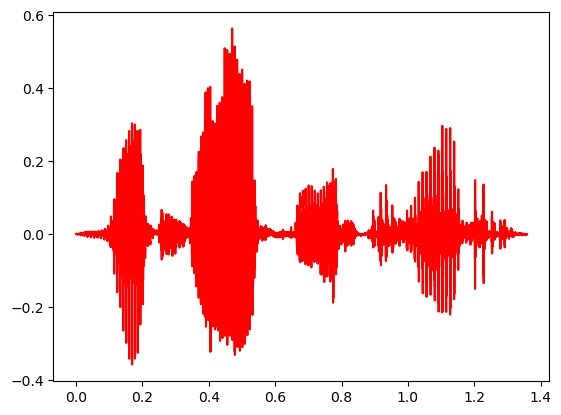

In [4]:
time_axis = np.arange(len(seg.wave))/16000    # this is a list of time values in seconds, from 0, to len(y)/fs
plt.plot(time_axis,seg.wave, color = "red") 

Audio(seg.wave,rate=16000)

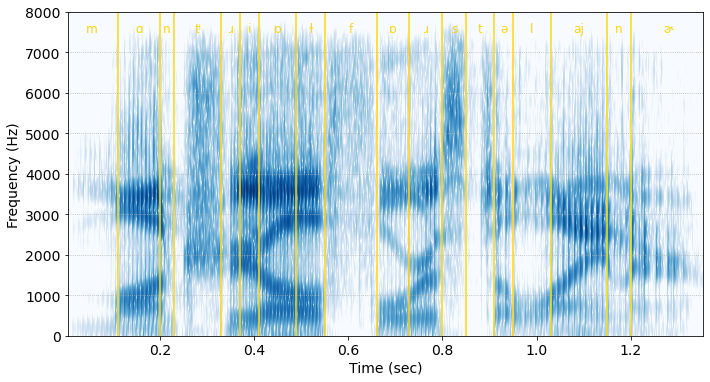

In [5]:
ret = phon.sgram(seg.wave,16000,cmap="Blues")
boundaries = ctm.phone_boundaries
ret[0].vlines(boundaries, 0, 8000,colors='#FFD60A')
for label, midpoint in ctm.labelled_midpoints:
    ret[0].annotate(label, (midpoint, 7500), color='#FFD60A', ha="center", fontsize="large")

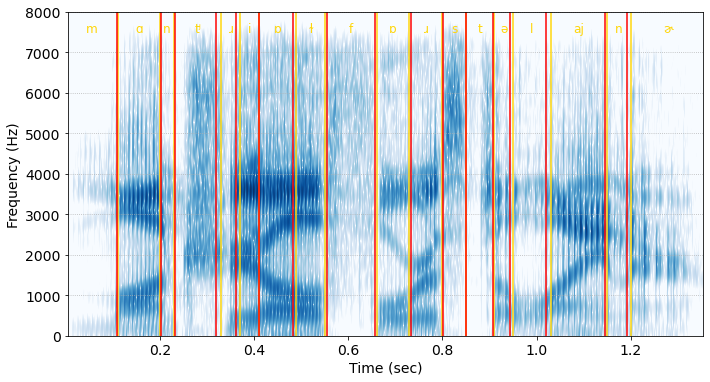

In [6]:
fine_tuned_ctm = aligner.fine_tune_alignments(utterance)
ret = phon.sgram(seg.wave,16000,cmap="Blues")
boundaries = ctm.phone_boundaries
ret[0].vlines(boundaries, 0, 8000,colors='#FFD60A')
boundaries = fine_tuned_ctm.phone_boundaries
ret[0].vlines(boundaries, 0, 8000,colors='red')
for label, midpoint in ctm.labelled_midpoints:
    ret[0].annotate(label, (midpoint, 7500), color='#FFD60A', ha="center", fontsize="large")